<a href="https://colab.research.google.com/github/klin-brycen/AI_training_tutorial/blob/main/AI%E5%AD%A6%E7%BF%92.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title 1. 初期設定

import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

# =========================
# クラス名
# =========================
CLASS_1_NAME = "Cat" # @param {type:"string"}
CLASS_2_NAME = "Dog" # @param {type:"string"}

# =========================
# 学習設定
# =========================
EPOCHS = 10 # @param [3, 5, 10, 15, 20, 30] {type:"raw"}
BATCH_SIZE = 16 # @param [8, 16, 32, 64] {type:"raw"}
LEARNING_RATE = 0.001 # @param [0.0001, 0.0003, 0.001, 0.003, 0.01] {type:"raw"}

IMAGE_SIZE = 224
DATASET_DIR = "/content/dataset"

CLASS_1_DIR = os.path.join(DATASET_DIR, CLASS_1_NAME)
CLASS_2_DIR = os.path.join(DATASET_DIR, CLASS_2_NAME)

os.makedirs(CLASS_1_DIR, exist_ok=True)
os.makedirs(CLASS_2_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("クラス1:", CLASS_1_NAME)
print("クラス2:", CLASS_2_NAME)
print("エポック数:", EPOCHS)
print("バッチサイズ:", BATCH_SIZE)
print("学習率:", LEARNING_RATE)
print("データ保存先:", DATASET_DIR)

TensorFlow version: 2.20.0
クラス1: Cat
クラス2: Dog
エポック数: 10
バッチサイズ: 16
学習率: 0.001
データ保存先: /content/dataset


In [5]:
# @title 2. クラス1の画像をアップロード

import os
import shutil
from google.colab import files

CLASS_1_NAME = "Cat" # @param {type:"string"}
DATASET_DIR = "/content/dataset"
CLASS_1_DIR = os.path.join(DATASET_DIR, CLASS_1_NAME)

os.makedirs(CLASS_1_DIR, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

print(f"{CLASS_1_NAME} の画像をアップロードしてください")

uploaded = files.upload()

count = 0
skipped = 0

for filename in uploaded.keys():
    if filename.lower().endswith(IMAGE_EXTENSIONS):
        save_name = f"{CLASS_1_NAME}_{len(os.listdir(CLASS_1_DIR)):04d}_{filename}"
        save_path = os.path.join(CLASS_1_DIR, save_name)

        shutil.move(filename, save_path)
        count += 1
    else:
        skipped += 1
        print("スキップ:", filename)

print("--------------------")
print(f"{CLASS_1_NAME} に {count} 枚追加しました")
print(f"現在の画像数: {len(os.listdir(CLASS_1_DIR))} 枚")

Cat の画像をアップロードしてください


Saving cat-2994836_1280.jpg to cat-2994836_1280.jpg
Saving cat-7647422_960_720.jpg to cat-7647422_960_720.jpg
Saving 28735832_m-768x511.jpg to 28735832_m-768x511.jpg
Saving cat-1909634_1280.jpg to cat-1909634_1280.jpg
Saving cat-2346302_1280.jpg to cat-2346302_1280.jpg
Saving R (1).jpg to R (1).jpg
Saving pngtree-cat-in-the-forest-at-autumn-colour-wallpapers-picture-image_2662730.jpg to pngtree-cat-in-the-forest-at-autumn-colour-wallpapers-picture-image_2662730.jpg
Saving R.jpg to R.jpg
Saving cat-1674658_1280.jpg to cat-1674658_1280.jpg
Saving animals-1930359_1280.jpg to animals-1930359_1280.jpg
--------------------
Cat に 10 枚追加しました
現在の画像数: 10 枚


In [6]:
# @title 3. クラス2の画像をアップロード

import os
import shutil
from google.colab import files

CLASS_2_NAME = "Dog" # @param {type:"string"}
DATASET_DIR = "/content/dataset"
CLASS_2_DIR = os.path.join(DATASET_DIR, CLASS_2_NAME)

os.makedirs(CLASS_2_DIR, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

print(f"{CLASS_2_NAME} の画像をアップロードしてください")

uploaded = files.upload()

count = 0
skipped = 0

for filename in uploaded.keys():
    if filename.lower().endswith(IMAGE_EXTENSIONS):
        save_name = f"{CLASS_2_NAME}_{len(os.listdir(CLASS_2_DIR)):04d}_{filename}"
        save_path = os.path.join(CLASS_2_DIR, save_name)

        shutil.move(filename, save_path)
        count += 1
    else:
        skipped += 1
        print("スキップ:", filename)

print("--------------------")
print(f"{CLASS_2_NAME} に {count} 枚追加しました")
print(f"現在の画像数: {len(os.listdir(CLASS_2_DIR))} 枚")

Dog の画像をアップロードしてください


Saving 928-1ef0c696dc54a5c4d4b52f353ba6e9b2.jpg to 928-1ef0c696dc54a5c4d4b52f353ba6e9b2.jpg
Saving 0a6dc7bc8bf185bb8e023fd508497d7b.jpg to 0a6dc7bc8bf185bb8e023fd508497d7b.jpg
Saving 柴犬_10.jpg to 柴犬_10.jpg
Saving DSC0022-3-1300x1068.jpg to DSC0022-3-1300x1068.jpg
Saving shiba.jpg to shiba.jpg
Saving shibainu-main-e1564733504943.jpeg to shibainu-main-e1564733504943.jpeg
Saving c_68_4.jpg to c_68_4.jpg
Saving dog-4427659_1280.jpg to dog-4427659_1280.jpg
Saving shiba-inu-7226744_1280.jpg to shiba-inu-7226744_1280.jpg
Saving 011kumakichi0327_TP_V.jpg to 011kumakichi0327_TP_V.jpg
Saving dog-2383585_960_720.jpg to dog-2383585_960_720.jpg
--------------------
Dog に 11 枚追加しました
現在の画像数: 11 枚


In [7]:
# @title 4. データ確認・読み込み

import os
import tensorflow as tf

DATASET_DIR = "/content/dataset"

IMAGE_SIZE = 224
BATCH_SIZE = 16 # @param [8, 16, 32, 64] {type:"raw"}

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

if not os.path.exists(DATASET_DIR):
    raise ValueError("datasetフォルダがありません。先に画像をアップロードしてください。")

class_dirs = []

for name in sorted(os.listdir(DATASET_DIR)):
    path = os.path.join(DATASET_DIR, name)

    if os.path.isdir(path):
        image_count = len([
            f for f in os.listdir(path)
            if f.lower().endswith(IMAGE_EXTENSIONS)
        ])

        if image_count > 0:
            class_dirs.append((name, image_count))

print("データ確認")
print("--------------------")

for class_name, image_count in class_dirs:
    print(f"{class_name}: {image_count} 枚")

print("--------------------")

if len(class_dirs) != 2:
    raise ValueError(
        f"検出されたクラス数が2ではありません。現在のクラス数: {len(class_dirs)}"
    )

for class_name, image_count in class_dirs:
    if image_count < 5:
        raise ValueError(
            f"{class_name} の画像が少なすぎます。最低5枚以上、できれば20枚以上入れてください。"
        )

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("検出したクラス:", class_names)
print("データ読み込み完了")

データ確認
--------------------
Cat: 10 枚
Dog: 11 枚
--------------------
Found 21 files belonging to 2 classes.
Using 17 files for training.
Found 21 files belonging to 2 classes.
Using 4 files for validation.
検出したクラス: ['Cat', 'Dog']
データ読み込み完了


In [8]:
# @title 5. AIモデルを作る

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# @title 6. 学習開始

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("学習完了")

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4706 - loss: 1.0831 - val_accuracy: 0.7500 - val_loss: 0.4599
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.4118 - loss: 0.8665 - val_accuracy: 1.0000 - val_loss: 0.2808
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.5882 - loss: 0.5935 - val_accuracy: 1.0000 - val_loss: 0.1987
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.8824 - loss: 0.3120 - val_accuracy: 1.0000 - val_loss: 0.1509
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 378ms/step - accuracy: 0.9412 - loss: 0.3396 - val_accuracy: 1.0000 - val_loss: 0.1210
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 378ms/step - accuracy: 1.0000 - loss: 0.1621 - val_accuracy: 1.0000 - val_loss: 0.1042
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step - accuracy: 1.0000 - loss: 0.1296 - val_accuracy: 1.0000 - val_loss: 0.0916
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step - accuracy: 1.0000 - loss: 0.1057 - val_accuracy: 1.0000 - val_loss: 0.

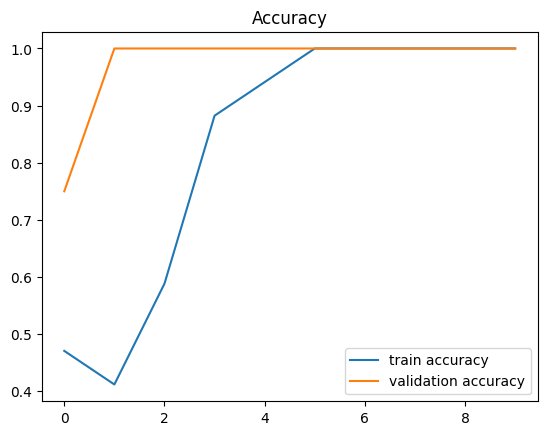

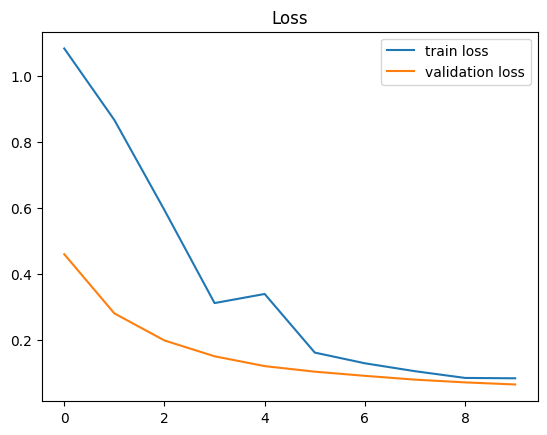

In [10]:
# @title 7. 学習結果を見る

plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.legend()
plt.title("Loss")
plt.show()

Saving animal-7642918_640.jpg to animal-7642918_640.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


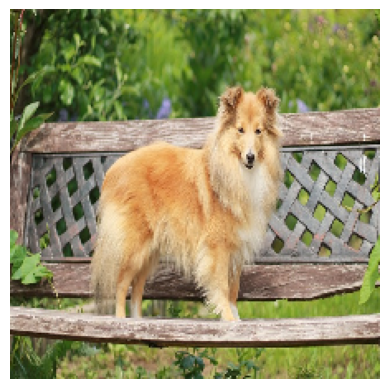

判定結果: Dog
信頼度: 89.41%

詳細:
Cat: 10.59%
Dog: 89.41%


In [11]:
# @title 8. 画像を判定する

uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename

    img = image.load_img(
        img_path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]

    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("判定結果:", predicted_class)
    print(f"信頼度: {confidence:.2f}%")

    print()
    print("詳細:")
    for class_name, score in zip(class_names, predictions):
        print(f"{class_name}: {score * 100:.2f}%")